# Phase 3: Role metrics and per-90 normalization

## From career totals to comparable per-90 rates, with a real minimum-minutes threshold

Phase 2 (with its addendum) left `population.csv` with career totals for
5636 outfield players, including the metrics needed for all four
functional roles. This notebook: confirms the population loads correctly
with the addendum columns, sets the minimum-minutes threshold using the
real distribution of career minutes (not a number picked in advance), and
computes per-90 rates from career totals.

---

# Fase 3: métricas por rol y normalización per 90

## De totales de carrera a tasas per 90 comparables, con un umbral mínimo de minutos real

La Fase 2 (con su addendum) dejó `population.csv` con totales de carrera
para 5636 jugadores de campo, incluyendo las métricas necesarias para los
cuatro roles funcionales. Este notebook: confirma que la población carga
bien con las columnas del addendum, fija el umbral mínimo de minutos
usando la distribución real de minutos de carrera (no un número elegido
de antemano), y calcula tasas per 90 a partir de los totales de carrera.

In [14]:
import pandas as pd

population = pd.read_csv("../data/processed/population.csv")

print(population.shape)
print(population.columns.tolist())

messi = population[population["name"].str.contains("Messi", case=False, na=False)]
print()
print(messi[["name", "totalPass", "totalOppositionHalfPasses", "accurateOppositionHalfPasses"]])

(5636, 29)
['id', 'goals', 'totalShots', 'onTargetScoringAttempt', 'shotOffTarget', 'totalContest', 'wonContest', 'wasFouled', 'fouls', 'keyPass', 'goalAssist', 'bigChanceCreated', 'bigChanceMissed', 'totalCross', 'accurateCross', 'totalPass', 'accuratePass', 'touches', 'duelWon', 'duelLost', 'hitWoodwork', 'totalOppositionHalfPasses', 'accurateOppositionHalfPasses', 'minutesPlayed', 'name', 'world_cups_played', 'first_world_cup', 'last_world_cup', 'matches_played']

             name  totalPass  totalOppositionHalfPasses  \
662  Lionel Messi     1563.0                     1288.0   

     accurateOppositionHalfPasses  
662                        1050.0  


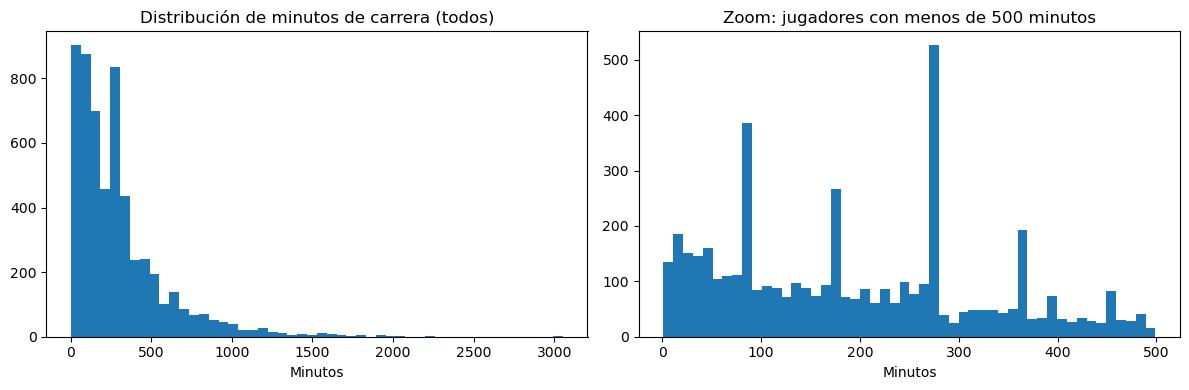

count    5636.000000
mean      294.025905
std       284.254707
min         1.000000
25%        90.000000
50%       231.500000
75%       373.000000
max      3054.000000
Name: minutesPlayed, dtype: float64

Jugadores con >= 90 minutos de carrera: 4454 de 5636 (79.0%)
Jugadores con >= 180 minutos de carrera: 3401 de 5636 (60.3%)
Jugadores con >= 270 minutos de carrera: 2488 de 5636 (44.1%)
Jugadores con >= 360 minutos de carrera: 1613 de 5636 (28.6%)
Jugadores con >= 450 minutos de carrera: 1135 de 5636 (20.1%)
Jugadores con >= 540 minutos de carrera: 827 de 5636 (14.7%)


In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(population["minutesPlayed"], bins=50)
axes[0].set_title("Distribución de minutos de carrera (todos)")
axes[0].set_xlabel("Minutos")

axes[1].hist(population[population["minutesPlayed"] < 500]["minutesPlayed"], bins=50)
axes[1].set_title("Zoom: jugadores con menos de 500 minutos")
axes[1].set_xlabel("Minutos")

plt.tight_layout()
plt.show()

print(population["minutesPlayed"].describe())
print()
for threshold in [90, 180, 270, 360, 450, 540]:
    n = (population["minutesPlayed"] >= threshold).sum()
    print(f"Jugadores con >= {threshold} minutos de carrera: {n} de {len(population)} ({n/len(population)*100:.1f}%)")

In [16]:
thresholds_to_test = [1, 90, 180, 270, 360, 450, 540, 720, 900]

print(f"{'Umbral':>8} {'N jugadores':>12} {'Media goles/90':>16} {'Std goles/90':>14} {'Máx goles/90':>14}")
for t in thresholds_to_test:
    subset = population[population["minutesPlayed"] >= t].copy()
    goals_per_90 = subset["goals"] / (subset["minutesPlayed"] / 90)
    print(f"{t:>8} {len(subset):>12} {goals_per_90.mean():>16.3f} {goals_per_90.std():>14.3f} {goals_per_90.max():>14.2f}")

  Umbral  N jugadores   Media goles/90   Std goles/90   Máx goles/90
       1         5636            0.107          0.350           9.00
      90         4454            0.105          0.225           2.52
     180         3401            0.111          0.211           2.52
     270         2488            0.114          0.199           1.50
     360         1613            0.130          0.203           1.50
     450         1135            0.140          0.209           1.50
     540          827            0.141          0.204           1.50
     720          460            0.158          0.213           1.08
     900          258            0.181          0.228           1.08


In [17]:
qualified = population[population["minutesPlayed"] >= 270].copy()
print(f"Jugadores que cumplen el umbral: {len(qualified)} de {len(population)}")

per_90_columns = [
    "goals", "totalShots", "onTargetScoringAttempt", "shotOffTarget",
    "totalContest", "wonContest", "wasFouled", "fouls",
    "keyPass", "goalAssist", "bigChanceCreated", "bigChanceMissed",
    "totalCross", "accurateCross", "totalPass", "accuratePass",
    "touches", "duelWon", "duelLost", "hitWoodwork",
    "totalOppositionHalfPasses", "accurateOppositionHalfPasses",
]

for col in per_90_columns:
    qualified[f"{col}_per90"] = qualified[col] / (qualified["minutesPlayed"] / 90)

messi_check = qualified[qualified["name"].str.contains("Messi", case=False, na=False)]
print(messi_check[["name", "goals_per90", "keyPass_per90", "totalOppositionHalfPasses_per90"]])

Jugadores que cumplen el umbral: 2488 de 5636
             name  goals_per90  keyPass_per90  totalOppositionHalfPasses_per90
662  Lionel Messi     0.618861       2.976424                        37.956778


## Assigning survived metrics to a role, or leaving them out

Surviving Phase 3's historical-coverage check (16 of 21 metrics with full
1966-2026 coverage go into a role) isn't the same question as belonging to
one of the four functional roles. That has to be a separate, explicit
decision, not an automatic consequence of coverage.

- **Finisher:** `goals`, `totalShots`, `onTargetScoringAttempt`.
  `shotOffTarget` is left out as redundant with the other two, and
  `hitWoodwork` stays as context rather than a primary efficiency metric.
- **Dribbler:** `totalContest`, `wonContest`, `wasFouled` (fouls drawn by
  taking players on, one of the original candidates for this role).
- **Chance creator:** `keyPass`, `goalAssist`, `bigChanceCreated`,
  `totalCross`/`accurateCross` (crossing is, functionally, creating a
  chance from the flank).
- **Play organizer:** `totalPass`, `accuratePass`,
  `totalOppositionHalfPasses`, `accurateOppositionHalfPasses`, `touches`
  (involvement in circulation is central to this role).

**Left out of the four-role framework entirely**, not because they're bad
metrics, but because they don't describe any of the four with precision:
`duelWon`/`duelLost` (a physical/defensive dimension that cuts across
every position, not specific to these four offensive/creative roles) and
`fouls` committed (discipline, not functional performance). `bigChanceMissed`
stays as context for the finisher role rather than a primary metric, since
it penalizes players who get into more good positions in the first place.

---

## Asignando las métricas sobrevivientes a un rol, o dejándolas afuera

Sobrevivir el chequeo de cobertura histórica de la Fase 3 (16 de 21
métricas con cobertura completa 1966-2026 entran a un rol) no es la misma
pregunta que pertenecer a uno de los cuatro roles funcionales. Tiene que
ser una decisión separada y explícita, no una consecuencia automática de
la cobertura.

- **Finalizador:** `goals`, `totalShots`, `onTargetScoringAttempt`.
  `shotOffTarget` queda afuera por redundante con las otras dos, y
  `hitWoodwork` se mantiene como contexto y no como métrica primaria de
  eficiencia.
- **Desequilibrante:** `totalContest`, `wonContest`, `wasFouled` (faltas
  recibidas por encarar rivales, una de las candidatas originales para
  este rol).
- **Creador de juego:** `keyPass`, `goalAssist`, `bigChanceCreated`,
  `totalCross`/`accurateCross` (centrar es, funcionalmente, generar una
  ocasión desde banda).
- **Organizador de juego:** `totalPass`, `accuratePass`,
  `totalOppositionHalfPasses`, `accurateOppositionHalfPasses`, `touches`
  (estar involucrado en la circulación es central para este rol).

**Quedan totalmente fuera del framework de los cuatro roles**, no porque
sean malas métricas, sino porque no describen ninguno de los cuatro con
precisión: `duelWon`/`duelLost` (una dimensión física/defensiva que
atraviesa todas las posiciones, no específica de estos cuatro roles
ofensivos/creativos) y `fouls` cometidas (disciplina, no rendimiento
funcional). `bigChanceMissed` se mantiene como contexto para el rol
finalizador y no como métrica primaria, porque penaliza a jugadores que
justamente se meten en más posiciones de gol.

In [18]:
role_metrics = {
    "finisher": ["goals", "totalShots", "onTargetScoringAttempt"],
    "dribbler": ["totalContest", "wonContest", "wasFouled"],
    "chance_creator": ["keyPass", "goalAssist", "bigChanceCreated", "totalCross", "accurateCross"],
    "play_organizer": ["totalPass", "accuratePass", "totalOppositionHalfPasses", "accurateOppositionHalfPasses", "touches"],
}

excluded_from_roles = ["duelWon", "duelLost", "fouls", "shotOffTarget", "hitWoodwork", "bigChanceMissed"]

all_role_cols = [c for cols in role_metrics.values() for c in cols]
print(f"Columnas asignadas a un rol: {len(all_role_cols)}")
print(f"Columnas excluidas del framework de roles: {len(excluded_from_roles)}")

# Confirmar que no me quedó ninguna de las 21 sin clasificar de un lado o del otro
all_21 = [
    "goals", "totalShots", "onTargetScoringAttempt", "shotOffTarget",
    "totalContest", "wonContest", "wasFouled", "fouls",
    "keyPass", "goalAssist", "bigChanceCreated", "bigChanceMissed",
    "totalCross", "accurateCross", "totalPass", "accuratePass",
    "touches", "duelWon", "duelLost", "hitWoodwork",
    "totalOppositionHalfPasses", "accurateOppositionHalfPasses",
]
unclassified = [c for c in all_21 if c not in all_role_cols and c not in excluded_from_roles]
print(f"Sin clasificar (debería ser vacío): {unclassified}")

Columnas asignadas a un rol: 16
Columnas excluidas del framework de roles: 6
Sin clasificar (debería ser vacío): []


## What each role metric actually measures

Some of these are self-explanatory, others aren't, and getting the
definition wrong would misread the whole role. Definitions below follow
the data provider's own glossary (Opta, the standard behind this kind of
event data), not intuition from the column name alone.

**Finisher**
- `goals`: goals scored.
- `totalShots`: every shot attempt, on target, off target, or blocked.
- `onTargetScoringAttempt`: shots that were on frame (would have gone in
  without a save or block).

**Dribbler**
- `totalContest`: attempted take-ons, trying to beat an opponent by
  running past them with the ball.
- `wonContest`: take-ons that succeeded.
- `wasFouled`: times the player was fouled by an opponent. This isn't
  limited to fouls drawn specifically while dribbling, it's a general
  count, included here because attacking players who repeatedly take
  opponents on tend to draw disproportionately more fouls than other
  roles.

**Chance creator**
- `keyPass`: the final pass that sets up a shot attempt that does *not*
  end in a goal. If the resulting shot scores, the pass is counted as
  `goalAssist` instead, the two categories don't overlap or stack.
- `goalAssist`: the pass immediately before a goal.
- `bigChanceCreated`: created a situation where a teammate should
  reasonably be expected to score, typically a one-on-one with the
  goalkeeper or a shot from very close range. A meaningfully higher bar
  than a key pass.
- `totalCross`/`accurateCross`: crosses attempted/completed into the box
  from a wide position, functionally a chance-creation action even though
  it isn't a `keyPass` unless it directly sets up a shot.

**Play organizer**
- `totalPass`/`accuratePass`: every pass attempted/completed, anywhere on
  the pitch.
- `totalOppositionHalfPasses`/`accurateOppositionHalfPasses`: the subset
  of those passes attempted/completed while positioned in the opposition's
  half, a proxy for advancing play into dangerous territory rather than
  circulating the ball safely in one's own half.
- `touches`: number of times the player touched the ball. One caveat
  worth flagging: some data providers count an entire close-control
  dribbling sequence (several touches in quick succession while running
  past a defender) as a single touch event, not one per contact, which
  can undercount players who dribble a lot relative to players who mostly
  pass.

**Excluded from the four roles** (already noted above, defined here for
completeness): `duelWon`/`duelLost` count contested individual battles for
the ball (tackles, aerial duels, 50-50s) won or lost, a physical dimension
that cuts across every position rather than describing one of these four
roles specifically. `fouls` are fouls committed, a discipline metric.
`shotOffTarget` and `hitWoodwork` are finishing context, not primary
metrics. `bigChanceMissed` penalizes getting into a big chance and not
scoring it, which would unfairly punish players who generate more of
those situations in the first place.

---

## Qué mide realmente cada métrica de rol

Algunas son evidentes, otras no, y entender mal la definición malinterpreta
todo el rol. Las definiciones de abajo siguen el glosario propio del
proveedor de datos (Opta, el estándar detrás de este tipo de datos de
eventos), no la intuición a partir del nombre de la columna.

**Finalizador**
- `goals`: goles convertidos.
- `totalShots`: todo intento de remate, al arco, desviado, o bloqueado.
- `onTargetScoringAttempt`: remates que iban al arco (hubieran entrado sin
  una atajada o bloqueo).

**Desequilibrante**
- `totalContest`: intentos de gambeta, tratar de superar a un rival
  encarándolo con la pelota.
- `wonContest`: gambetas que salieron bien.
- `wasFouled`: veces que el jugador recibió una falta de un rival. No se
  limita a faltas recibidas específicamente al gambetear, es un conteo
  general, incluido acá porque los jugadores ofensivos que encaran
  rivales repetidamente tienden a recibir desproporcionadamente más
  faltas que otros roles.

**Creador de juego**
- `keyPass`: el pase final que habilita un remate que *no* termina en gol.
  Si ese remate convierte, el pase se cuenta como `goalAssist` en su
  lugar, las dos categorías no se superponen ni se suman.
- `goalAssist`: el pase inmediatamente anterior a un gol.
- `bigChanceCreated`: crear una situación donde razonablemente se
  esperaría que un compañero convierta, típicamente mano a mano con el
  arquero o un remate desde muy cerca. Una vara bastante más alta que un
  pase clave.
- `totalCross`/`accurateCross`: centros intentados/completados al área
  desde una posición abierta, funcionalmente una acción de creación de
  ocasión aunque no cuente como `keyPass` a menos que habilite un remate
  directamente.

**Organizador de juego**
- `totalPass`/`accuratePass`: todo pase intentado/completado, en
  cualquier parte de la cancha.
- `totalOppositionHalfPasses`/`accurateOppositionHalfPasses`: el
  subconjunto de esos pases intentados/completados estando posicionado en
  campo rival, un proxy de hacer avanzar el juego hacia territorio
  peligroso en vez de circular la pelota de forma segura en campo propio.
- `touches`: cantidad de veces que el jugador tocó la pelota. Una
  salvedad para tener en cuenta: algunos proveedores de datos cuentan una
  secuencia completa de gambeta de control cercano (varios toques
  seguidos mientras supera a un defensor) como un solo evento de toque,
  no uno por contacto, lo que puede subestimar a jugadores que gambetean
  mucho en relación a los que sobre todo pasan.

**Excluidas de los cuatro roles** (ya mencionado arriba, definidas acá
para que quede completo): `duelWon`/`duelLost` cuentan disputas
individuales por la pelota (entradas, duelos aéreos, 50-50) ganadas o
perdidas, una dimensión física que atraviesa todas las posiciones en vez
de describir uno de estos cuatro roles específicamente. `fouls` son
faltas cometidas, una métrica de disciplina. `shotOffTarget` y
`hitWoodwork` son contexto de finalización, no métricas primarias.
`bigChanceMissed` penaliza meterse en una ocasión clara y no convertirla,
lo que castigaría injustamente a jugadores que generan más de esas
situaciones en primer lugar.

In [19]:
qualified = population[population["minutesPlayed"] >= 270].copy()
print(f"Jugadores que cumplen el umbral: {len(qualified)} de {len(population)}")

for role, cols in role_metrics.items():
    for col in cols:
        qualified[f"{col}_per90"] = qualified[col] / (qualified["minutesPlayed"] / 90)

messi_check = qualified[qualified["name"].str.contains("Messi", case=False, na=False)]
print(messi_check[["name", "goals_per90", "keyPass_per90", "bigChanceCreated_per90",
                    "totalOppositionHalfPasses_per90"]])

qualified.to_csv("../data/processed/role_metrics.csv", index=False)
print(f"\nGuardado: {qualified.shape[0]} jugadores, {qualified.shape[1]} columnas")

Jugadores que cumplen el umbral: 2488 de 5636
             name  goals_per90  keyPass_per90  bigChanceCreated_per90  \
662  Lionel Messi     0.618861       2.976424                0.707269   

     totalOppositionHalfPasses_per90  
662                        37.956778  

Guardado: 2488 jugadores, 45 columnas


## Phase 3 conclusion

Checked historical availability for every originally-candidate metric
against the real extraction, not just the Phase 0 spot-check: xG/xA
(2022-2026 only) and progressive-carry metrics (spotty pre-2006 coverage)
were dropped; `totalOppositionHalfPasses`/`accurateOppositionHalfPasses`
(present across all 16 tournaments) were added as the organizer role's
progression proxy, folded back into Phase 2's population build.

Surviving coverage isn't the same as belonging to a role: of the 21
metrics that passed the coverage check, 16 were explicitly assigned to
one of the four functional roles (finisher, dribbler, chance creator, play
organizer), and 5 were deliberately left out of the role framework
(`duelWon`/`duelLost`, `fouls`, `shotOffTarget`, `hitWoodwork`,
`bigChanceMissed`), not for lacking data, but for not describing one of
the four roles with precision. Each surviving metric's exact definition
was confirmed against the data provider's own glossary rather than
assumed from the column name, since terms like `keyPass` and
`bigChanceCreated` have specific, non-obvious meanings that change how
the numbers should be read.

Set the minimum-minutes threshold at 270 (3 full matches) by testing
goals-per-90 mean and standard deviation across candidate thresholds on
the real population: the standard deviation bottoms out exactly at 270
and rises past it, marking where small-sample noise gives way to a
selection bias in the other direction. 270 minutes also reads as a
complete group stage under the classic 32-team World Cup format.

**Result:** `data/processed/role_metrics.csv`, 2488 players (of 5636) who
meet the threshold, with career totals for every metric and per-90 rates
for the 16 metrics assigned to a role. This is the population Phase 4
(role correlations) and Phase 5 (multi-role elite count) will work from.

---

## Conclusión de la Fase 3

Se revisó la disponibilidad histórica real de cada métrica originalmente
candidata contra la extracción completa, no solo el spot-check de la Fase
0: xG/xA (solo 2022-2026) y las métricas de conducción progresiva
(cobertura irregular antes de 2006) se descartaron;
`totalOppositionHalfPasses`/`accurateOppositionHalfPasses` (presentes en
los 16 torneos) se agregaron como proxy de progresión del rol organizador,
incorporadas de vuelta a la construcción de la población de la Fase 2.

Sobrevivir la cobertura no es lo mismo que pertenecer a un rol: de las 21
métricas que pasaron el chequeo de cobertura, 16 se asignaron
explícitamente a uno de los cuatro roles funcionales (finalizador,
desequilibrante, creador de juego, organizador), y 5 quedaron
deliberadamente afuera del framework de roles (`duelWon`/`duelLost`,
`fouls`, `shotOffTarget`, `hitWoodwork`, `bigChanceMissed`), no por falta
de datos, sino por no describir con precisión ninguno de los cuatro
roles. La definición exacta de cada métrica sobreviviente se confirmó
contra el glosario propio del proveedor de datos en vez de asumirse por
el nombre de la columna, ya que términos como `keyPass` y
`bigChanceCreated` tienen significados específicos y no obvios que
cambian cómo hay que leer los números.

Se fijó el umbral mínimo de minutos en 270 (3 partidos completos)
probando la media y desviación estándar de goles per 90 en varios
umbrales candidatos sobre la población real: la desviación estándar toca
su mínimo justo en 270 y sube después, marcando dónde el ruido de muestra
chica le cede el paso a un sesgo de selección en la otra dirección. 270
minutos también se lee como una fase de grupos completa bajo el formato
clásico de 32 equipos del Mundial.

**Resultado:** `data/processed/role_metrics.csv`, 2488 jugadores (de
5636) que cumplen el umbral, con totales de carrera para cada métrica y
tasas per 90 para las 16 métricas asignadas a un rol. Esta es la
población desde la que van a trabajar la Fase 4 (correlación entre roles)
y la Fase 5 (conteo de élite multi-rol).